In [267]:
%load_ext autoreload
%autoreload 2 
    
from __init__ import PRP; import sys
sys.path.append(PRP + 'Diffusion_model')
sys.path.append(PRP + 'Results/analysis_scripts/')

import os
from configs.base_config import TrainingConfig
from pipelines.pipeline_tensor import DDPMPipeline_Tensor
from pipelines.State import Observer
import torch
from Diffusion_Model.pipelines.new_constraint import *
from DataLoader import get_dataloader, get_infos
from TransformFields import TransformationPipeline
from torch.autograd.functional import vjp
from functools import partial

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
pwd

'/Users/emeunier/Desktop/Projets/DINO-Fusion/Results/notebooks'

In [3]:
model_path = f'{os.environ["OCEANDATA"]}/models/dino-fusion/tav0h83b/'
pipeline = DDPMPipeline_Tensor.from_pretrained(model_path).to('mps')

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

In [4]:
config = TrainingConfig()
config.data_file='/Volumes/LoCe/oceandata//Dino-Fusion/dino_1_4_degree_coarse_240125.tar'
observer = Observer('data', config)

Reading infos in /Volumes/LoCe/oceandata//Dino-Fusion/dino_1_4_degree_coarse_240125.tar


In [321]:
tr = TransformationPipeline(get_infos(config.data_file), config.fields, config.normalisation, device='mps')
train_dataloader = get_dataloader(config.data_file, tr, batch_size=1)
idt = iter(train_dataloader)
data = next(idt)

fixed_start = torch.randn_like(data)

Reading infos in /Volumes/LoCe/oceandata//Dino-Fusion/dino_1_4_degree_coarse_240125.tar


In [333]:
loss = MeanDensityProfile(observer=observer,profile=np.loadtxt(f'{PRP}/Results/analysis_scripts/mean_density_train_strided.txt'),
                                result='strided')
gradient_f =  LossAD(loss)
"""
constraint = Constraint() 
projection = OptimProjection(objective, eps=0.1, max_opt_steps=10)
"""

constraint = GradientConstraint(Beta(beta_init=0.00001, beta_type='eq', params_beta = {'eta':1e-5}), gradient_f)
projection = BorderZero(observer=observer)

In [334]:
gen = fixed_start.clone()

with torch.no_grad() :
    pbar = pipeline.progress_bar(pipeline.scheduler.timesteps)
    for t in pbar: #pipeline.scheduler.timesteps
        model_output = pipeline.unet(gen, t).sample
        increment_model = pipeline.scheduler.step(model_output, t, gen).prev_sample # x - dt* ∇log p(x) 
        
        constraint_dt = constraint(gen, t) # 𝛼∇C(x)
        gen = increment_model - constraint_dt
        
        gen = projection(gen)
        pbar.set_description(f'Loss : {objective(gen) :.2e} Beta {constraint.beta.value:.3e}')

  0%|          | 0/1000 [00:00<?, ?it/s]

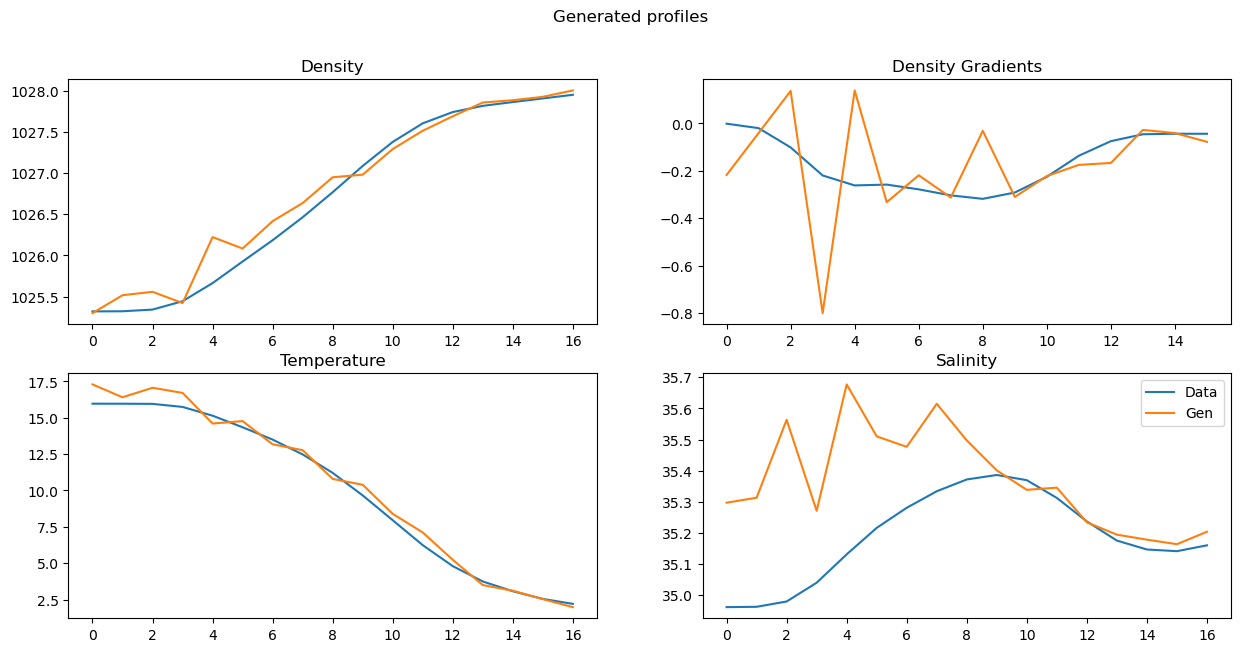

In [335]:
fig, axs = plt.subplots(2,2, figsize=(15,7))

fig.suptitle(f'Generated profiles')

funs = {'Density' : partial(observer.density, result='strided'),
        'Density Gradients' : partial(observer.density_gradient, result='strided'),
        'Temperature' : (lambda x : observer.unnormalized(x, result='strided')['toce']),
        'Salinity' : (lambda x : observer.unnormalized(x, result='strided')['soce'])}

fs = {'Data' : data, 'Gen' : gen}

axs = axs.flatten()

for i, (k, v) in enumerate(funs.items()) : 
    axs[i].set_title(k)
    for fk, fv in fs.items() : 
        axs[i].plot(v(fv).nanmean(axis=(-1,-2))[:, :-1].T.cpu(), label=fk)
axs[-1].legend()

# GD - Latent

First using the chain rule we can find the gradients of our constraint which technically avoid for optimisation through the steps

$$
\begin{align}
C(x) &= ||g(x) -  z||^2 \to \nabla_x C(x) = 2 J_g(x)^T (g(x) - z)  
\end{align}
$$

In [325]:
grad_autograd = gradient_f(gen)

g = partial(gradient_f.loss.observer.density_profile, result=gradient_f.loss.result)
diff = (gradient_f.loss.mean_density[None, :] - g(gen))

prim, grad_v = vjp(g, gen, -2*diff)

((grad_autograd - grad_v)**2).sum()

tensor(0., device='mps:0')

Thus we can define a new gradient algorithm : 


$$
\begin{align}
d_t x &= \nabla_x f(x) + \beta \nabla_x C(x) = \nabla_x f(x) + \beta [ 2 J_g(x)^T (g(x) - z) ]  \\
d_t \beta &= \frac{\eta}{N} ||\nabla_x C(x)||^2
\end{align}
$$

In this setup $\beta \in \mathbb R$, although we can consider $\beta \in \mathbb R^n$ where the constraint is applied with a different strenght to each pixel of the input, in this case we could simply consider : 


$$
d_t \beta = \eta (\nabla_x C(x))^2
$$

In [338]:
loss = MeanDensityProfile(observer=observer,profile=np.loadtxt(f'{PRP}/Results/analysis_scripts/mean_density_train_strided.txt'),
                                result='strided')
gradient_f =  LossAD(loss)

constraint = GradientConstraint(Beta(beta_init=0.00001, beta_type='eq', params_beta = {'eta':1e-5}), gradient_f)
projection = BorderZero(observer=observer)

In [353]:
beta_type = 'tensor'
gen = fixed_start.clone()

gradient_f.loss.mean_density = gradient_f.loss.mean_density.to(gen)
g = partial(gradient_f.loss.observer.density_profile, result=gradient_f.loss.result)

with torch.no_grad() :
    pbar = pipeline.progress_bar(pipeline.scheduler.timesteps)
    for t in pbar: #pipeline.scheduler.timesteps
        model_output = pipeline.unet(gen, t).sample
        increment_model = pipeline.scheduler.step(model_output, t, gen).prev_sample # x - dt* ∇log p(x) 
        
        diff = (gradient_f.loss.mean_density[None, :] - g(gen))
        _, grad_loss = vjp(g, gen, -2*diff)
        if beta_type == 'scalar' :
            constraint.beta.update(t, torch.mean(torch.sum(grad_loss**2, dim=-1)))
        elif beta_type == 'tensor' :
            constraint.beta.update(t, grad_loss**2)
        
        gen = increment_model - constraint.beta.value*grad_loss

        
        gen = projection(gen)
        pbar.set_description(f'Loss : {loss(gen) :.2e} Beta {constraint.beta.value.mean():.3e} Nans : {gen.isnan().sum()}')

  0%|          | 0/1000 [00:00<?, ?it/s]

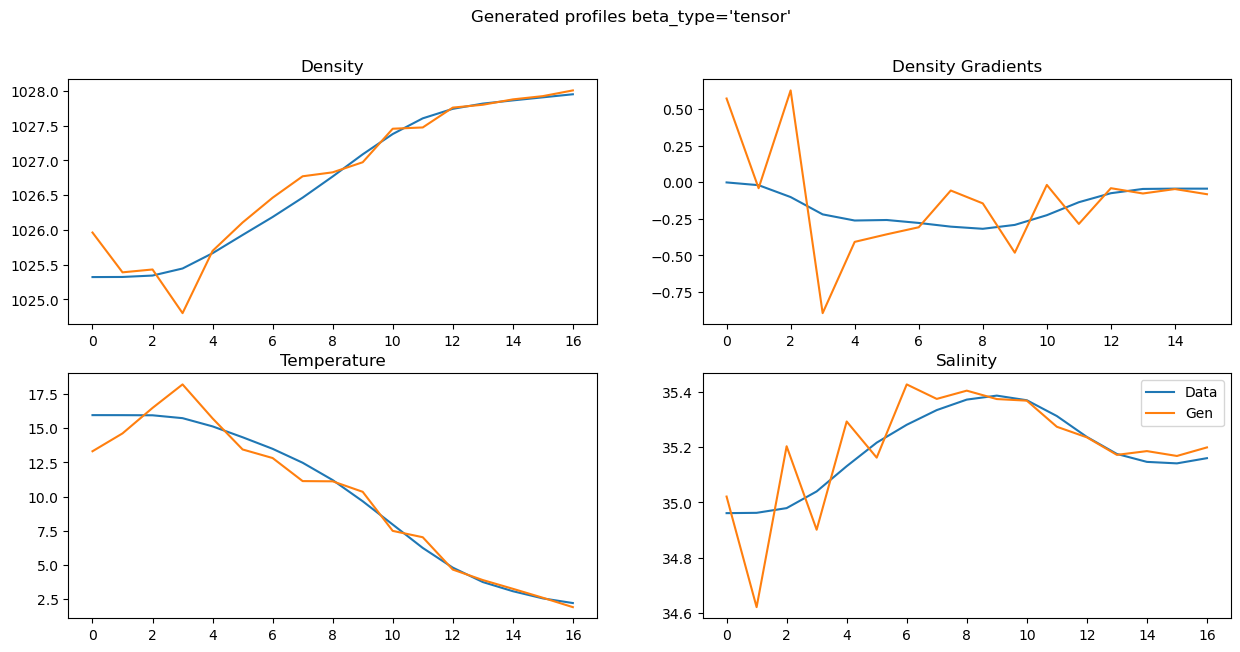

In [354]:
fig, axs = plt.subplots(2,2, figsize=(15,7))

fig.suptitle(f'Generated profiles {beta_type=}')

funs = {'Density' : partial(observer.density, result='strided'),
        'Density Gradients' : partial(observer.density_gradient, result='strided'),
        'Temperature' : (lambda x : observer.unnormalized(x, result='strided')['toce']),
        'Salinity' : (lambda x : observer.unnormalized(x, result='strided')['soce'])}

fs = {'Data' : data, 'Gen' : gen}

axs = axs.flatten()

for i, (k, v) in enumerate(funs.items()) : 
    axs[i].set_title(k)
    for fk, fv in fs.items() : 
        axs[i].plot(v(fv).nanmean(axis=(-1,-2))[:, :-1].T.cpu(), label=fk)
axs[-1].legend()

# SAL - Latent

In [382]:
loss = MeanDensityProfile(observer=observer,profile=np.loadtxt(f'{PRP}/Results/analysis_scripts/mean_density_train_strided.txt'),
                                result='strided')
gradient_f =  LossAD(loss)

constraint = GradientConstraint(Beta(beta_init=0.00001, beta_type='eq', params_beta = {'eta':1e-5}), gradient_f)
projection = BorderZero(observer=observer)

In [383]:
#Density constraint
gradient_f.loss.mean_density = gradient_f.loss.mean_density.to(gen)

g = lambda x : observer.density_profile(x, result='strided')
projection_admm = lambda g_x : gradient_f.loss.mean_density[None, :].repeat((g_x.shape[0],1))

In [384]:
rho = 1
eta = 1e-4

In [387]:
gen = fixed_start.clone()

mu = torch.zeros_like(g(gen))
gen_z = projection_admm(g(gen))

pbar = pipeline.progress_bar(pipeline.scheduler.timesteps)
for t in pbar: #pipeline.scheduler.timesteps
    var = pipeline.scheduler._get_variance(t, None)**0.5
    
    with torch.no_grad() :
        model_output = pipeline.unet(gen, t).sample
        gen = pipeline.scheduler.step(model_output, t, gen).prev_sample # x - dt* ∇log p(x) 
    
    g_x, dg_x_v =  vjp(g, gen, mu + g(gen) - gen_z)
    
    gen -= rho * dg_x_v                 

    g_gen = g(gen)
    gen_z = projection_admm(g_gen + mu + var * torch.randn_like(g_gen))
    
    mu += eta*(g_gen - gen_z)
    pbar.set_description(f'Loss : {loss(gen) :.2e} Beta {mu.mean():.3e} Nans : {gen.isnan().sum()}')

    gen = projection(gen)
    #gen_z = projection(gen_z)
    
    #print(t, gen.isnan().sum(), gen.max(), gen.min())
    if gen.isnan().sum() > 0 : 
        break

  0%|          | 0/1000 [00:00<?, ?it/s]

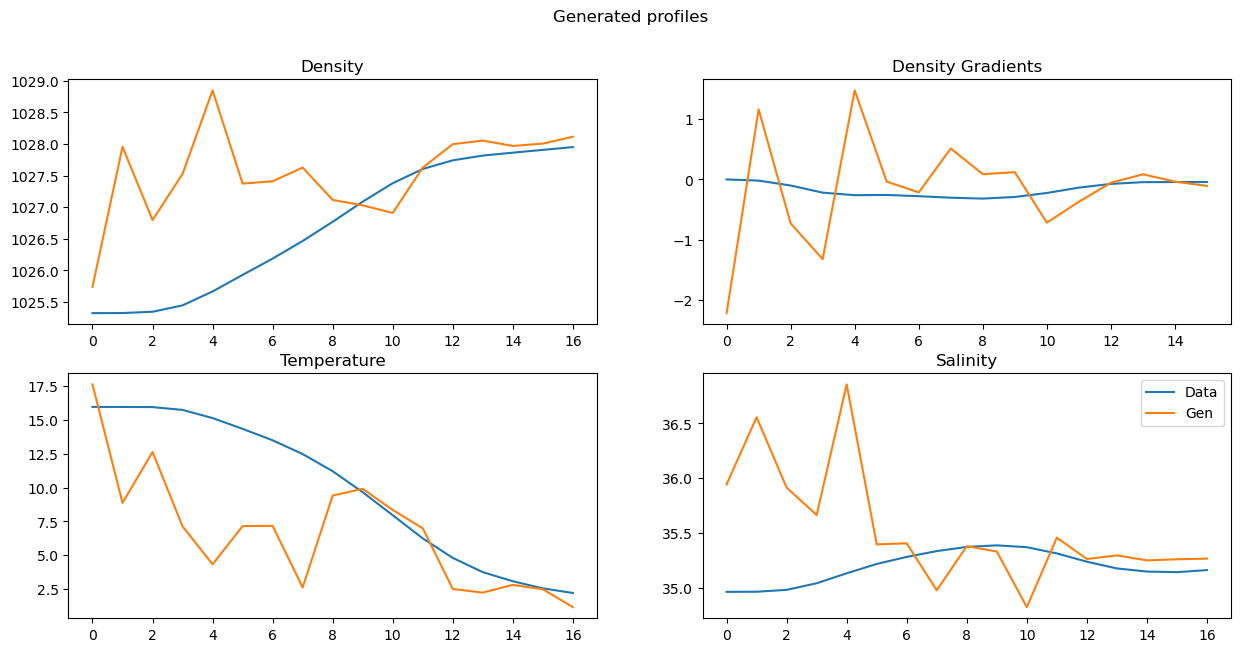

In [381]:
fig, axs = plt.subplots(2,2, figsize=(15,7))

fig.suptitle(f'Generated profiles')

funs = {'Density' : partial(observer.density, result='strided'),
        'Density Gradients' : partial(observer.density_gradient, result='strided'),
        'Temperature' : (lambda x : observer.unnormalized(x, result='strided')['toce']),
        'Salinity' : (lambda x : observer.unnormalized(x, result='strided')['soce'])}

fs = {'Data' : data, 'Gen' : gen}

axs = axs.flatten()

for i, (k, v) in enumerate(funs.items()) : 
    axs[i].set_title(k)
    for fk, fv in fs.items() : 
        axs[i].plot(v(fv).nanmean(axis=(-1,-2))[:, :-1].T.cpu(), label=fk)
axs[-1].legend()